In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
def list_fix(df):
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(lambda x: x if x is None else x.replace('[', '').replace(']', '').split(', '))
            df[col] = df[col].apply(lambda x: x[0] if len(x) == 1 else x)
    return df

data = pd.read_csv('ellipsis.csv')
data = list_fix(data)

ud_no_punct = (data[data['ud_pred_deprel'] != 'punct'])[['id', 'ud_test_head', 'ud_test_deprel', 'ud_test_deps_id','ud_test_deps_deprel', 'ud_pred_head', 'ud_pred_deprel', 'ud_pred_deps_id', 'ud_pred_deps_deprel', 'text', 'sent_id']]
str_no_punct = (data[data['str_pred_deprel'] != 'punct'])[['id', 'str_test_head', 'str_test_deprel', 'str_test_deps_id', 'str_test_deps_deprel', 'str_pred_head', 'str_pred_deprel', 'str_pred_deps_id', 'str_pred_deps_deprel', 'text', 'sent_id']]

In [3]:
heads = data[['id', 'ud_test_head', 'ud_test_deps_id', 'ud_pred_head', 'ud_pred_deps_id', 'str_test_head', 'str_test_deps_id','str_pred_head', 'str_pred_deps_id', 'text', 'sent_id']]
heads = heads.rename(columns={'ud_test_head': 'ud_test', 'ud_test_deps_head': 'ud_test_deps', 'ud_pred_head': 'ud_pred', 'ud_pred_deps_head': 'ud_pred_deps', 'str_test_head': 'str_test', 'str_test_deps_head': 'str_test_deps', 'str_pred_head': 'str_pred', 'str_pred_deps_head': 'str_pred_deps'})

deprels = data[['id', 'ud_test_deprel', 'ud_test_deps_deprel', 'ud_pred_deprel', 'ud_pred_deps_deprel', 'str_test_deprel', 'str_test_deps_deprel','str_pred_deprel', 'str_pred_deps_deprel', 'text', 'sent_id']]
deprels = deprels.rename(columns={'ud_test_deprel': 'ud_test', 'ud_test_deps_deprel': 'ud_test_deps', 'ud_pred_deprel': 'ud_pred', 'ud_pred_deps_deprel': 'ud_pred_deps', 'str_test_deprel': 'str_test', 'str_test_deps_deprel': 'str_test_deps', 'str_pred_deprel': 'str_pred', 'str_pred_deps_deprel': 'str_pred_deps'})

deprels.head(1)

,id,ud_test,ud_test_deps,ud_pred,ud_pred_deps,str_test,str_test_deps,str_pred,str_pred_deps,text,sent_id
0,30,conj,"['iobj', 'advmod', 'nummod']",conj,"['punct', 'iobj', 'nummod:gov']",сент-соч,"['дат-субъект', 'огранич', 'количест']",сочин,"['punct', 'дат-субъект', 'количест']",[Моя любовь к буйным пляскам вынудила мать сог...,341_2015Blokadnoe_detstvo


#### Точность предсказания главного слова и типа зависимости для обоих корпусов:

In [4]:
def get_accuracy(df, test, pred):
    return round(len(df[df[test] == df[pred]]) / len(df) * 100, 2)

print(f'UD head accuracy: {get_accuracy(heads, "ud_test", "ud_pred")}%')
print(f'UD deprel accuracy: {get_accuracy(deprels, "ud_test", "ud_pred")}%')
print('-' * 50)
print(f'SynTagRus head accuracy: {get_accuracy(heads, "str_test", "str_pred")}%')
print(f'SynTagRus deprel accuracy: {get_accuracy(deprels, "str_test", "str_pred")}%')

UD head accuracy: 39.81%
UD deprel accuracy: 36.41%
--------------------------------------------------
SynTagRus head accuracy: 43.2%
SynTagRus deprel accuracy: 37.86%


Без учёта присвоенной связи пунктуации `punct`:

In [5]:
print(f'UD head accuracy: {get_accuracy(ud_no_punct, "ud_test_head", "ud_pred_head")}%')
print(f'UD deprel accuracy: {get_accuracy(ud_no_punct, "ud_test_deprel", "ud_pred_deprel")}%')
print('-' * 50)
print(f'SynTagRus head accuracy: {get_accuracy(str_no_punct, "str_test_head", "str_pred_head")}%')
print(f'SynTagRus deprel accuracy: {get_accuracy(str_no_punct, "str_test_deprel", "str_pred_deprel")}%')

UD head accuracy: 61.95%
UD deprel accuracy: 66.37%
--------------------------------------------------
SynTagRus head accuracy: 76.15%
SynTagRus deprel accuracy: 71.56%


#### Распределение правильных и предсказанных типов зависимости у эллипсиса для обоих корпусов:

In [6]:
def get_percentage_df(df, column):
    df_count = df.groupby(column).size().reset_index(name='percentage')
    df_count = df_count.sort_values(by='percentage', ascending=False).reset_index(drop=True)
    df_count['percentage'] = round(df_count['percentage'] / len(df) * 100, 2)
    return df_count

ud_test_deprel_distribution = get_percentage_df(deprels, 'ud_test')
str_test_deprel_distribution = get_percentage_df(deprels, 'str_test')

ud_pred_deprel_distribution = get_percentage_df(deprels, 'ud_pred')
str_pred_deprel_distribution = get_percentage_df(deprels, 'str_pred')

ud_pred_deprel_distribution_no_punct = ud_pred_deprel_distribution[ud_pred_deprel_distribution['ud_pred'] != 'punct']
str_pred_deprel_distribution_no_punct = str_pred_deprel_distribution[str_pred_deprel_distribution['str_pred'] != 'punct']

In [7]:
colors = plt.get_cmap('tab20').colors

ud_labels = list(set(ud_test_deprel_distribution['ud_test'].head(10)) | set(ud_pred_deprel_distribution['ud_pred'].head(11)))
str_labels = list(set(str_test_deprel_distribution['str_test'].head(10)) | set(str_pred_deprel_distribution['str_pred'].head(11)))

ud_palette = {deprel: color for deprel, color in zip(ud_labels, colors)}
str_palette = {deprel: color for deprel, color in zip(str_labels, colors)}

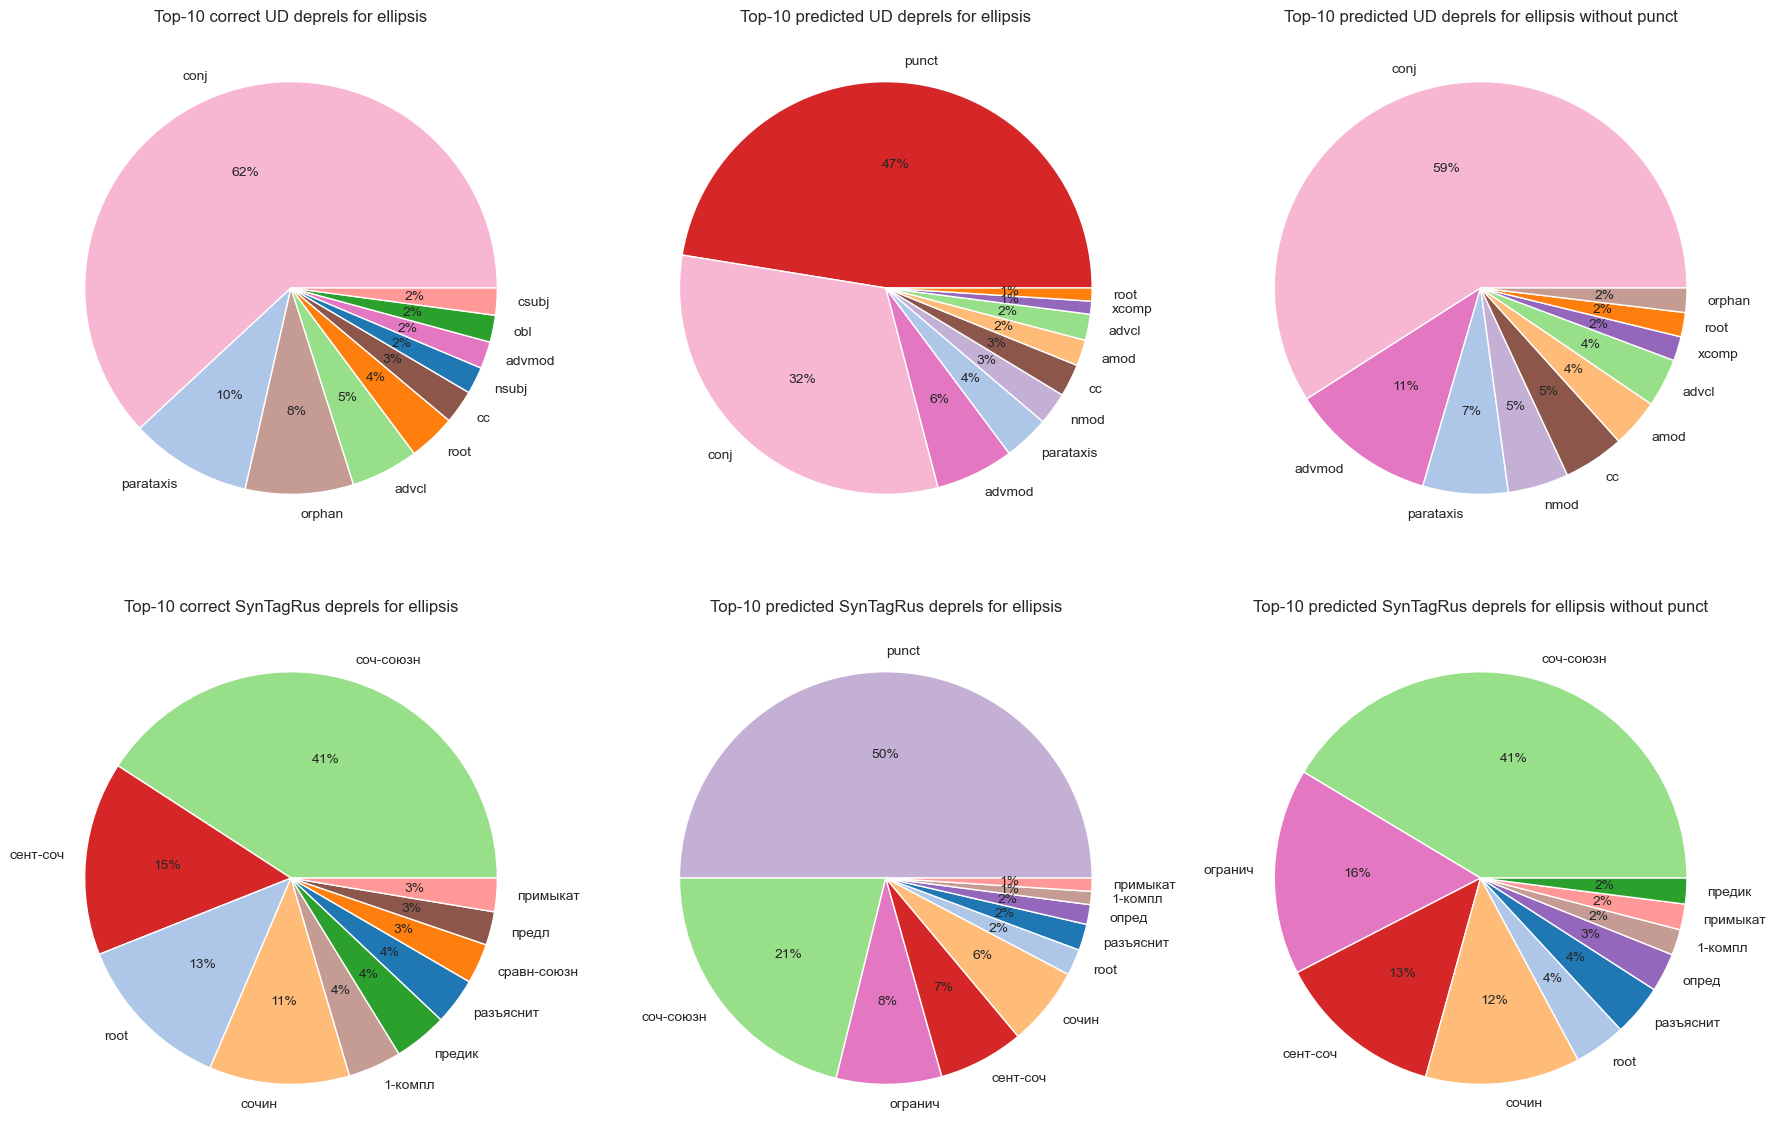

In [8]:
def autopct_more_than_1(pct):
    return ('%1.f%%' % pct) if pct > 1 else ''

plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plt.pie(ud_test_deprel_distribution['percentage'].head(10), labels=ud_test_deprel_distribution['ud_test'].head(10), autopct=autopct_more_than_1, colors=[ud_palette[deprel] for deprel in ud_test_deprel_distribution['ud_test'].head(10)])
plt.title("Top-10 correct UD deprels for ellipsis")

plt.subplot(2, 3, 2)
plt.pie(ud_pred_deprel_distribution['percentage'].head(10), labels=ud_pred_deprel_distribution['ud_pred'].head(10), autopct=autopct_more_than_1, colors=[ud_palette[deprel] for deprel in ud_pred_deprel_distribution['ud_pred'].head(10)])
plt.title("Top-10 predicted UD deprels for ellipsis")

plt.subplot(2, 3, 3)
plt.pie(ud_pred_deprel_distribution_no_punct['percentage'].head(10), labels=ud_pred_deprel_distribution_no_punct['ud_pred'].head(10), autopct=autopct_more_than_1, colors=[ud_palette[deprel] for deprel in ud_pred_deprel_distribution_no_punct['ud_pred'].head(10)])
plt.title("Top-10 predicted UD deprels for ellipsis without punct")

plt.subplot(2, 3, 4)
plt.pie(str_test_deprel_distribution['percentage'].head(10), labels=str_test_deprel_distribution['str_test'].head(10), autopct=autopct_more_than_1, colors=[str_palette[deprel] for deprel in str_test_deprel_distribution['str_test'].head(10)])
plt.title("Top-10 correct SynTagRus deprels for ellipsis")

plt.subplot(2, 3, 5)
plt.pie(str_pred_deprel_distribution['percentage'].head(10), labels=str_pred_deprel_distribution['str_pred'].head(10), autopct=autopct_more_than_1, colors=[str_palette[deprel] for deprel in str_pred_deprel_distribution['str_pred'].head(10)])
plt.title("Top-10 predicted SynTagRus deprels for ellipsis")

plt.subplot(2, 3, 6)
plt.pie(str_pred_deprel_distribution_no_punct['percentage'].head(10), labels=str_pred_deprel_distribution_no_punct['str_pred'].head(10), autopct=autopct_more_than_1, colors=[str_palette[deprel] for deprel in str_pred_deprel_distribution_no_punct['str_pred'].head(10)])
plt.title("Top-10 predicted SynTagRus deprels for ellipsis without punct")

plt.tight_layout()
plt.show()

#### Точность присоединения зависимых от эллипсиса слов и их отношения

In [9]:
deps = data[['id', 'ud_test_deps_id', 'ud_test_deps_deprel', 'ud_pred_deps_id', 'ud_pred_deps_deprel', 'str_test_deps_id', 'str_test_deps_deprel', 'str_pred_deps_id', 'str_pred_deps_deprel', 'text', 'sent_id']]

ud_deps_no_punct = (data[data['ud_pred_deprel'] != 'punct'])[['id', 'ud_test_deps_id', 'ud_test_deps_deprel', 'ud_pred_deps_id', 'ud_pred_deps_deprel', 'text', 'sent_id']]
str_deps_no_punct = (data[data['str_pred_deprel'] != 'punct'])[['id', 'str_test_deps_id', 'str_test_deps_deprel', 'str_pred_deps_id', 'str_pred_deps_deprel', 'text', 'sent_id']]

deps_heads = data[['id', 'ud_test_deps_id', 'ud_pred_deps_id', 'str_test_deps_id', 'str_pred_deps_id', 'text', 'sent_id']]
deps_heads = deps_heads.rename(columns={'ud_test_deps_id': 'ud_test', 'ud_pred_deps_id': 'ud_pred', 'str_test_deps_id': 'str_test', 'str_pred_deps_id': 'str_pred'})

deps.head(1)

,id,ud_test_deps_id,ud_test_deps_deprel,ud_pred_deps_id,ud_pred_deps_deprel,str_test_deps_id,str_test_deps_deprel,str_pred_deps_id,str_pred_deps_deprel,text,sent_id
0,30,"[27, 28, 29]","['iobj', 'advmod', 'nummod']","[26, 27, 29]","['punct', 'iobj', 'nummod:gov']","[27, 28, 29]","['дат-субъект', 'огранич', 'количест']","[26, 27, 29]","['punct', 'дат-субъект', 'количест']",[Моя любовь к буйным пляскам вынудила мать сог...,341_2015Blokadnoe_detstvo


In [10]:
def get_deps_accuracy(df, test, pred):
    df['total'] = df[test].apply(lambda x: len(x))
    df['correct'] = df.apply(lambda x: len(set(x[test]) & set(x[pred])), axis=1)
    return round(df['correct'].sum() / df['total'].sum() * 100, 2)

def get_deps_deprel_accuracy(df, test, pred, test_deprel, pred_deprel):
        df['correct_head'] = df.apply(lambda x: [x[test].index(dep) if (dep in x[test]) else -1 for dep in x[pred]], axis=1)
        df['correct_deprel'] = df.apply(lambda x: [1 if (x[test_deprel][test_i] == x[pred_deprel][pred_i]) else 0 for pred_i, test_i in enumerate(x['correct_head']) if test_i != -1], axis=1)
        df['total'] = df['correct_head'].apply(lambda x: len(x))
        df['correct deprel'] = df['correct_deprel'].apply(lambda x: sum(x))
        return round(df['correct deprel'].sum() / df['total'].sum() * 100, 2)

In [11]:
print(f'UD dependent attachment accuracy: {get_deps_accuracy(deps_heads, "ud_test", "ud_pred")}%')
print(f'UD dependent deprel accuracy: {get_deps_deprel_accuracy(deps.copy(), "ud_test_deps_id", "ud_pred_deps_id", "ud_test_deps_deprel", "ud_pred_deps_deprel")}%')
print('-' * 50)
print(f'SynTagRus dependent attachment accuracy: {get_deps_accuracy(deps_heads, "str_test", "str_pred")}%')
print(f'SynTagRus dependent deprel accuracy: {get_deps_deprel_accuracy(deps.copy(), "str_test_deps_id", "str_pred_deps_id", "str_test_deps_deprel", "str_pred_deps_deprel")}%')

UD dependent attachment accuracy: 37.55%
UD dependent deprel accuracy: 73.09%
--------------------------------------------------
SynTagRus dependent attachment accuracy: 36.76%
SynTagRus dependent deprel accuracy: 65.37%


Без учёта присвоенной связи пунктуации `punct`:

In [12]:
print(f'UD dependent attachment accuracy: {get_deps_accuracy(ud_deps_no_punct, "ud_test_deps_id", "ud_pred_deps_id")}%')
print(f'UD dependent deprel accuracy: {get_deps_deprel_accuracy(ud_deps_no_punct, "ud_test_deps_id", "ud_pred_deps_id", "ud_test_deps_deprel", "ud_pred_deps_deprel")}%')
print('-' * 50)
print(f'SynTagRus dependent attachment accuracy: {get_deps_accuracy(str_deps_no_punct, "str_test_deps_id", "str_pred_deps_id")}%')
print(f'SynTagRus dependent deprel accuracy: {get_deps_deprel_accuracy(str_deps_no_punct, "str_test_deps_id", "str_pred_deps_id", "str_test_deps_deprel", "str_pred_deps_deprel")}%')

UD dependent attachment accuracy: 64.31%
UD dependent deprel accuracy: 75.23%
--------------------------------------------------
SynTagRus dependent attachment accuracy: 67.21%
SynTagRus dependent deprel accuracy: 69.07%
